# QFT Circuit - Transpilation Across IBM Topologies
### How the Qiskit compiler reshapes a more connectivity-demanding circuit for real hardware

**Goal:** Build a 7-qubit Quantum Fourier Transform (QFT) circuit and compile it onto three physical qubit topologies.  
Track how **circuit depth**, **CX gate count**, and **SWAP overhead** change with topology and optimisation level.

---


## 1. Setup

In [1]:
# Install dependencies (run once)
# %pip install qiskit qiskit-aer matplotlib numpy

In [2]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath(".")))

import warnings
warnings.filterwarnings("ignore")

# Helper modules (circuits.py / topologies.py / transpiler.py / plotting.py)
from circuits   import build_qft
from topologies import get_topologies
from transpiler import run_transpilation, print_report, BASIS_GATES, OPT_LEVELS
from plotting   import (
    plot_logical_circuit,
    plot_topologies,
    plot_opt3_bars,
    plot_depth_vs_opt,
    plot_cx_by_opt,
    plot_heatmap,
)

import matplotlib
matplotlib.use("inline")
import matplotlib.pyplot as plt

N_QUBITS = 7
print(f"Qiskit ready  |  {N_QUBITS}-qubit QFT  |  basis: {BASIS_GATES}")


Qiskit ready  |  7-qubit QFT  |  basis: ['cx', 'u']


## 2. Logical QFT Circuit

The **Quantum Fourier Transform (QFT)** maps computational-basis amplitudes into the phase/frequency basis:

$$|x\rangle \mapsto \frac{1}{\sqrt{2^n}} \sum_{y=0}^{2^n-1} e^{2\pi ixy/2^n}|y\rangle$$

Construction: Hadamards plus controlled phase rotations between many qubit pairs, followed by optional output-order swaps.


In [14]:
logical = build_qft(N_QUBITS)
print(logical.draw())


        ┌───┐                                                                 »
   q_0: ┤ H ├─■────────■─────────────■─────────────────■──────────────────────»
        └───┘ │P(π/2)  │       ┌───┐ │                 │                      »
   q_1: ──────■────────┼───────┤ H ├─┼────────■────────┼─────────■────────────»
                       │P(π/4) └───┘ │        │P(π/2)  │         │       ┌───┐»
   q_2: ───────────────■─────────────┼────────■────────┼─────────┼───────┤ H ├»
                                     │P(π/8)           │         │P(π/4) └───┘»
   q_3: ─────────────────────────────■─────────────────┼─────────■────────────»
                                                       │P(π/16)               »
   q_4: ───────────────────────────────────────────────■──────────────────────»
                                                                              »
   q_5: ──────────────────────────────────────────────────────────────────────»
                                        

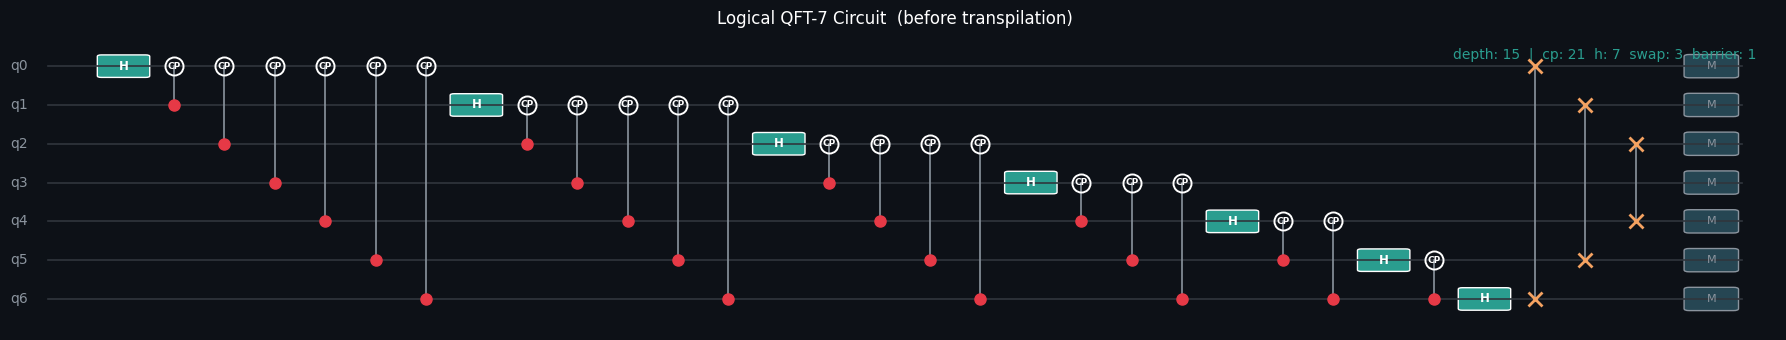

In [4]:
fig = plot_logical_circuit(N_QUBITS, logical)
plt.show()

## 3. Physical Qubit Topologies

We test three coupling maps that represent distinct classes of real hardware.

| Topology | Connectivity | Representative IBM device |
|---|---|---|
| **Linear Chain** | 1-D nearest-neighbour | ibmq_5_yorktown (early devices) |
| **Heavy-Hex** | Sparse hexagonal lattice | ibm_cairo, ibm_nazca, Eagle/Heron |
| **Full Graph** | All-to-all | Ideal simulator (theoretical baseline) |


In [5]:
topologies = get_topologies(N_QUBITS)

for name, t in topologies.items():
    cmap  = t["map"]
    edges = len(list(cmap.get_edges())) // 2
    avg_degree = (2 * edges) / cmap.size()
    print(f"{t['short']:<12}  qubits={cmap.size()}  edges={edges}  avg_degree={avg_degree:.2f}")

Linear        qubits=7  edges=6  avg_degree=1.71
Heavy-Hex     qubits=19  edges=20  avg_degree=2.11
Full Graph    qubits=7  edges=21  avg_degree=6.00


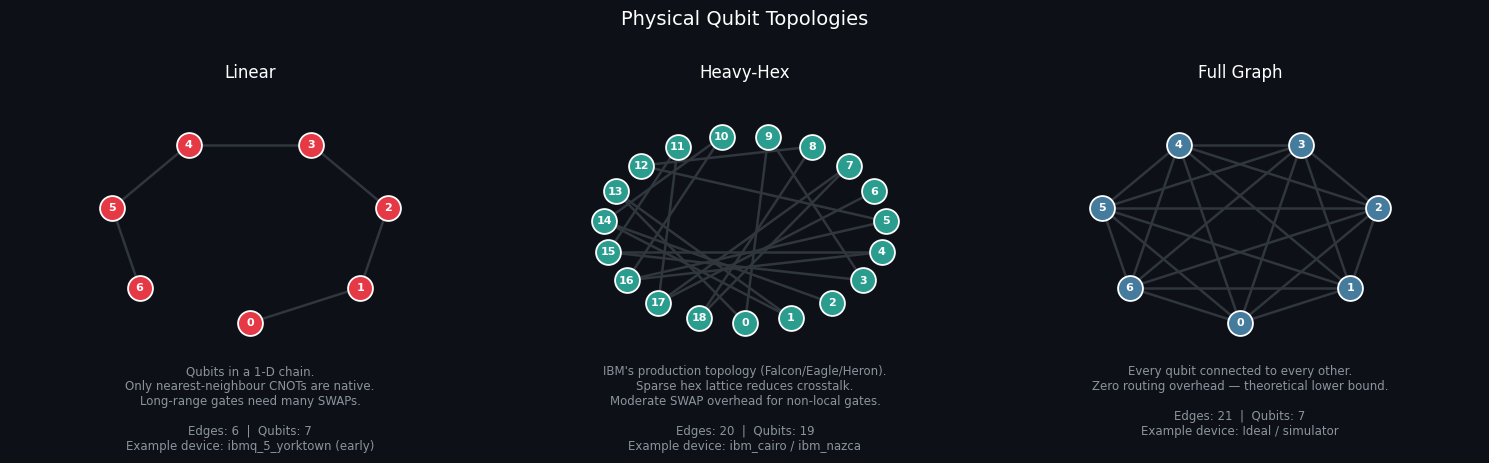

In [6]:
fig = plot_topologies(topologies)
plt.show()

## 4. Transpilation

`qiskit.compiler.transpile` performs four passes:

1. **Unrolling** — decompose gates into the basis `{CX, U}`
2. **Layout** — assign logical qubits to physical qubits
3. **Routing** — insert SWAP gates so every 2-qubit gate acts on adjacent qubits
4. **Optimisation** — cancel redundant gates, merge rotations

We sweep all four **optimisation levels** (0 = none, 3 = maximum).


In [7]:
results = run_transpilation(logical, topologies)
print_report(logical, topologies, results)

  QFT-7 Transpilation Report  |  basis: ['cx', 'u']

Logical circuit  →  depth=15  cp=21  h=7  measure=7  swap=3  barrier=1
Topology-free basis decomposition  →  cx=51

Topology   Opt   Depth     CX      U   SWAP≈   Total
----------------------------------------------------
Linear       0     105    126     70      25     196
Linear       1     110    120     70      23     190
Linear       2      82     75    101       8     176
Linear       3      82     75    101       8     176

Heavy-Hex    0     124    186     70      45     256
Heavy-Hex    1     114    102     70      17     172
Heavy-Hex    2      93     70     86       6     156
Heavy-Hex    3      93     70     86       6     156

Full Graph   0      49     51     70       0     121
Full Graph   1      49     51     70       0     121
Full Graph   2      46     42     70       0     112
Full Graph   3      46     42     70       0     112



## 5. Results - Opt-0 vs Opt-3 Snapshot

The bars below compare the naive compiled cost against the highest optimisation level for each topology.


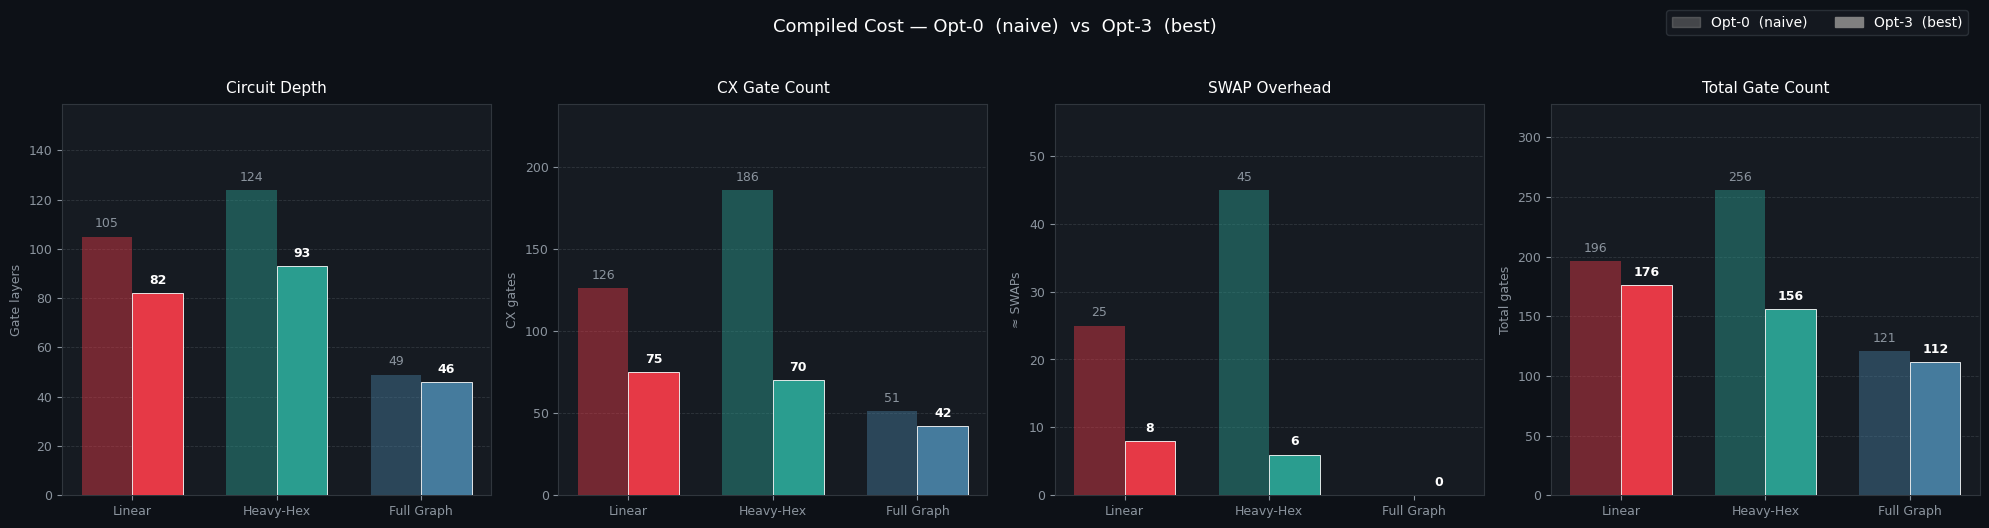

In [8]:
fig = plot_opt3_bars(topologies, results)
plt.show()

## 6. Depth vs Optimisation Level

QFT contains controlled phase rotations between many qubit pairs. On sparse coupling maps, the transpiler must choose a layout and route non-local interactions with additional CX gates. The line plot shows how much the optimisation passes reduce that cost.


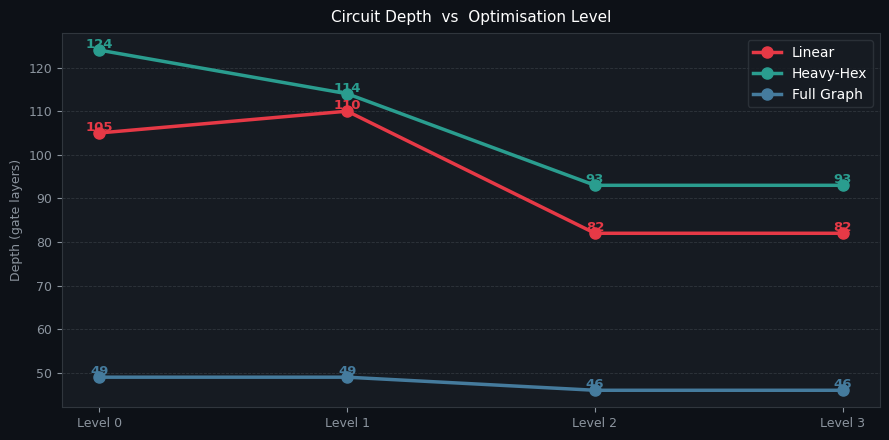

In [9]:
fig = plot_depth_vs_opt(topologies, results)
plt.show()


## 7. CX Gate Count — All Optimisation Levels


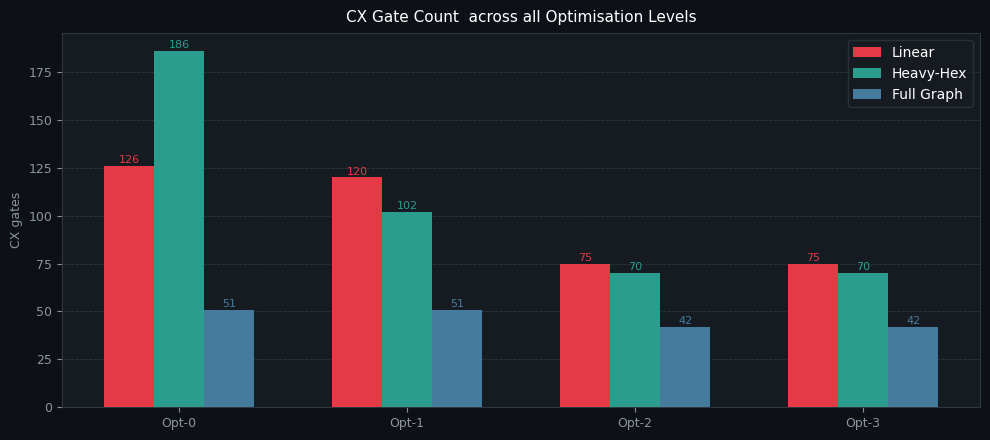

In [10]:
fig = plot_cx_by_opt(topologies, results)
plt.show()


## 8. Summary Heatmap  (All Optimisation Levels)

Each cell shows the **raw value**; colour encodes relative cost column-by-column  
(green = cheapest, red = most expensive).


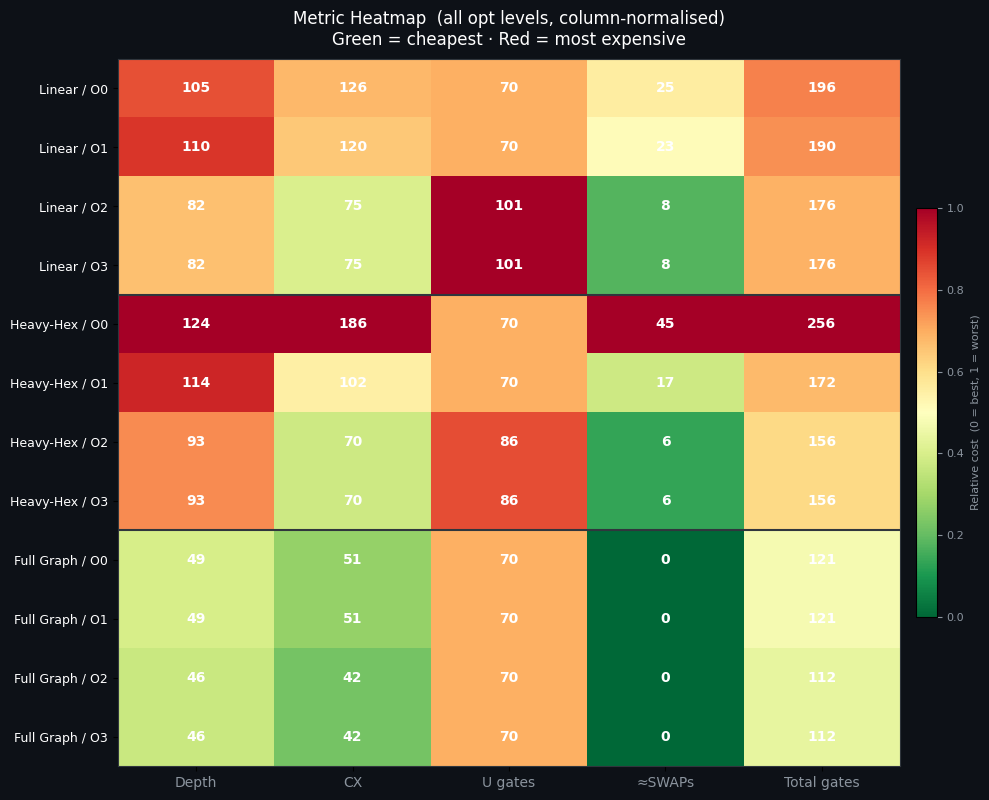

In [11]:
fig = plot_heatmap(topologies, results)
plt.show()


## 9. Analysis & Conclusions

...

### Try it yourself

Change `N_QUBITS`, set `build_qft(N_QUBITS, do_swaps=False)` to omit final bit-reversal swaps, or edit `topologies.py` to add a custom coupling map.
